In [5]:
import torch

print(torch.cuda.memory_allocated()/1024**3, "GB")
print(torch.cuda.memory_reserved()/1024**3, "GB")

0.0 GB
0.0 GB


In [1]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA RTX A2000 Laptop GPU


In [2]:
!pip install nibabel matplotlib numpy scikit-learn tqdm opencv-python

In [3]:
!pip install monai SimpleITK

In [4]:
!pip install pandas

In [6]:
import sys

print(sys.executable)

D:\annacondadeep\envs\torch_env\python.exe


In [7]:
import sys

!{sys.executable} -m pip install pandas

In [12]:
# ============================================
# 🔹 1. R2U-net Model (4CH)
# ============================================


Epoch 1/20

🔵 TRAINING
Loss: 0.2757 | Dice: 0.8393 | Acc: 0.9484

🟠 VALIDATION
Loss: 1.0517 | Dice: 0.1045 | Acc: 0.6192

Epoch 2/20

🔵 TRAINING
Loss: 0.1026 | Dice: 0.9084 | Acc: 0.9713

🟠 VALIDATION
Loss: 1.0661 | Dice: 0.0413 | Acc: 0.7541

Epoch 3/20

🔵 TRAINING
Loss: 0.0909 | Dice: 0.9139 | Acc: 0.9731

🟠 VALIDATION
Loss: 1.1436 | Dice: 0.0560 | Acc: 0.6959

Epoch 4/20

🔵 TRAINING
Loss: 0.0846 | Dice: 0.9186 | Acc: 0.9745

🟠 VALIDATION
Loss: 1.1450 | Dice: 0.0583 | Acc: 0.7590

Epoch 5/20

🔵 TRAINING
Loss: 0.0752 | Dice: 0.9269 | Acc: 0.9772

🟠 VALIDATION
Loss: 1.1686 | Dice: 0.0527 | Acc: 0.7560

Epoch 6/20

🔵 TRAINING
Loss: 0.0720 | Dice: 0.9299 | Acc: 0.9780

🟠 VALIDATION
Loss: 1.1606 | Dice: 0.0485 | Acc: 0.7487

Epoch 7/20

🔵 TRAINING
Loss: 0.0691 | Dice: 0.9326 | Acc: 0.9788

🟠 VALIDATION
Loss: 1.3537 | Dice: 0.0316 | Acc: 0.7569

Epoch 8/20

🔵 TRAINING
Loss: 0.0631 | Dice: 0.9383 | Acc: 0.9806

🟠 VALIDATION
Loss: 1.3533 | Dice: 0.0345 | Acc: 0.7566

Epoch 9/20

🔵 TRAINING


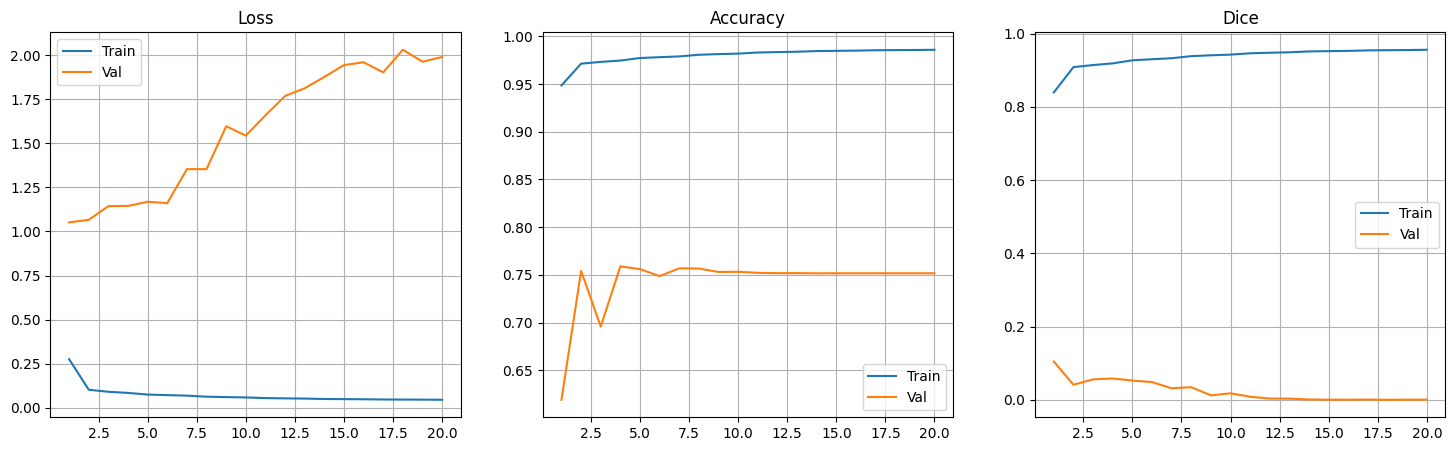

In [27]:
# ============================================
# 🔹 Imports
# ============================================

import os, gc, warnings
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import nibabel as nib
import pandas as pd
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import classification_report

warnings.filterwarnings("ignore")
torch.backends.cudnn.benchmark = True


# ============================================
# 🔹 Paths
# ============================================

BASE_PATH = r"D:\CMR-MULTI\CINE_MULTI"

TRAIN_IMAGE_PATH = os.path.join(BASE_PATH,"4CH_TR","image")
TRAIN_MASK_PATH  = os.path.join(BASE_PATH,"4CH_TR","anno")

VAL_IMAGE_PATH   = os.path.join(BASE_PATH,"4CH_VAL","image")
VAL_MASK_PATH    = os.path.join(BASE_PATH,"4CH_VAL","anno")


# ============================================
# 🔹 Dataset
# ============================================

class NiftiDataset(Dataset):
    def __init__(self,img_dir,mask_dir):
        self.samples=[]
        self.img_dir=img_dir
        self.mask_dir=mask_dir

        for f in sorted(os.listdir(img_dir)):
            depth=nib.load(os.path.join(img_dir,f)).shape[2]
            for i in range(depth):
                self.samples.append((f,i))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self,idx):
        f,i=self.samples[idx]

        img=nib.load(os.path.join(self.img_dir,f)).dataobj[:,:,i]
        mask=nib.load(os.path.join(self.mask_dir,f)).dataobj[:,:,i]

        img=np.array(img,dtype=np.float32)
        mask=np.array(mask,dtype=np.int64)

        if img.max()>img.min():
            img=(img-img.min())/(img.max()-img.min())
        else:
            img=np.zeros_like(img)

        img=torch.tensor(img).unsqueeze(0)
        mask=torch.tensor(mask)

        img=F.interpolate(img.unsqueeze(0),(256,256),mode='bilinear').squeeze(0)
        mask=F.interpolate(mask.unsqueeze(0).unsqueeze(0).float(),
                           (256,256),
                           mode='nearest').squeeze().long()

        return img,mask


# ============================================
# 🔹 Split
# ============================================

train_ds=NiftiDataset(TRAIN_IMAGE_PATH,TRAIN_MASK_PATH)
val_ds=NiftiDataset(VAL_IMAGE_PATH,VAL_MASK_PATH)

train_size=int(0.75*len(train_ds))
test_size=len(train_ds)-train_size

train_data,test_data=random_split(train_ds,[train_size,test_size])


# ============================================
# 🔹 Loaders
# ============================================

device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_loader=DataLoader(train_data,batch_size=4,shuffle=True)
val_loader=DataLoader(val_ds,batch_size=4)
test_loader=DataLoader(test_data,batch_size=4)


# ============================================
# 🔹 R2U-NET
# ============================================

NUM_CLASSES=6


class RecurrentBlock(nn.Module):
    def __init__(self,out_c,t=2):
        super().__init__()
        self.t=t
        self.conv=nn.Sequential(
            nn.Conv2d(out_c,out_c,3,padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True)
        )

    def forward(self,x):
        h=self.conv(x)
        for _ in range(self.t-1):
            h=self.conv(x+h)
        return h


class RRCNN(nn.Module):
    def __init__(self,in_c,out_c,t=2):
        super().__init__()
        self.conv1x1=nn.Conv2d(in_c,out_c,1)
        self.rcnn=nn.Sequential(
            RecurrentBlock(out_c,t),
            RecurrentBlock(out_c,t)
        )

    def forward(self,x):
        return self.rcnn(self.conv1x1(x))


class R2UNet(nn.Module):
    def __init__(self,n_classes):
        super().__init__()

        self.d1=RRCNN(1,64)
        self.d2=RRCNN(64,128)
        self.d3=RRCNN(128,256)
        self.bn=RRCNN(256,512)

        self.p=nn.MaxPool2d(2)

        self.u3=nn.ConvTranspose2d(512,256,2,2)
        self.u2=nn.ConvTranspose2d(256,128,2,2)
        self.u1=nn.ConvTranspose2d(128,64,2,2)

        self.c3=RRCNN(512,256)
        self.c2=RRCNN(256,128)
        self.c1=RRCNN(128,64)

        self.out=nn.Conv2d(64,n_classes,1)

    def forward(self,x):
        x1=self.d1(x)
        x2=self.d2(self.p(x1))
        x3=self.d3(self.p(x2))
        x4=self.bn(self.p(x3))

        x=self.u3(x4)
        x=self.c3(torch.cat([x,x3],1))

        x=self.u2(x)
        x=self.c2(torch.cat([x,x2],1))

        x=self.u1(x)
        x=self.c1(torch.cat([x,x1],1))

        return self.out(x)


# ============================================
# 🔹 Metrics 
# ============================================

def dice_score(pred,target):
    pred=torch.argmax(pred,1)
    dices=[]

    for c in range(1,NUM_CLASSES):
        p=(pred==c).float()
        t=(target==c).float()

        if t.sum()==0:
            continue

        inter=(p*t).sum()
        dice=(2*inter+1e-6)/(p.sum()+t.sum()+1e-6)
        dices.append(dice)

    return torch.mean(torch.stack(dices)) if len(dices)>0 else torch.tensor(0.0,device=pred.device)


def acc(pred,target):
    pred=torch.argmax(pred,1)
    return (pred==target).float().mean()


# ============================================
# 🔹 LOSS 
# ============================================

class DiceLoss(nn.Module):
    def forward(self,logits,target):
        probs=torch.softmax(logits,1)
        target=F.one_hot(target,NUM_CLASSES).permute(0,3,1,2).float()

        inter=(probs*target).sum((2,3))
        union=probs.sum((2,3))+target.sum((2,3))

        dice=(2*inter+1e-6)/(union+1e-6)
        return 1 - dice.clamp(0,1).mean()


# Balanced weights
weights=torch.tensor([1.0,1.5,1.5,2.0,1.5,1.5]).to(device)

ce=nn.CrossEntropyLoss(weight=weights)
dice_loss=DiceLoss()


# ============================================
# 🔹 Model + Optimizer
# ============================================

model = R2UNet(NUM_CLASSES).to(device)

opt = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-5
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    opt,
    mode='min',
    factor=0.5,
    patience=2
)


# ============================================
# 🔹 Checkpoint + History
# ============================================

checkpoint_path="r2unet_ckpt1.pth"
history_path="r2unet_history1.csv"

train_loss,val_loss=[],[]
train_dice,val_dice=[],[]
train_acc,val_acc=[],[]


# ============================================
# 🔹 TRAIN LOOP
# ============================================

EPOCHS=20

for ep in range(EPOCHS):

    # ---------------- TRAIN ----------------
    model.train()
    tl,td,ta=0,0,0

    for x,y in train_loader:
        x,y=x.to(device),y.to(device)

        out=model(x)
        loss = 0.5 * ce(out,y) + 0.5 * dice_loss(out,y)

        opt.zero_grad()
        loss.backward()
        opt.step()

        tl+=loss.item()
        td+=dice_score(out,y).item()
        ta+=acc(out,y).item()

    # ---------------- VAL ----------------
    model.eval()
    vl,vd,va=0,0,0
    

    with torch.no_grad():
        for x,y in val_loader:
            x,y=x.to(device),y.to(device)

            out=model(x)
            loss = 0.5 * ce(out,y) + 0.5 * dice_loss(out,y)

            vl+=loss.item()
            vd+=dice_score(out,y).item()
            va+=acc(out,y).item()

    tl/=len(train_loader); vl/=len(val_loader)
    td/=len(train_loader); vd/=len(val_loader)
    ta/=len(train_loader); va/=len(val_loader)
    scheduler.step(vl)
    train_loss.append(tl); val_loss.append(vl)
    train_dice.append(td); val_dice.append(vd)
    train_acc.append(ta); val_acc.append(va)

    # PRINT CLEAN
    print("\n" + "="*60)
    print(f"Epoch {ep+1}/{EPOCHS}")

    print("\n🔵 TRAINING")
    print(f"Loss: {tl:.4f} | Dice: {td:.4f} | Acc: {ta:.4f}")

    print("\n🟠 VALIDATION")
    print(f"Loss: {vl:.4f} | Dice: {vd:.4f} | Acc: {va:.4f}")

    # CHECKPOINT
    torch.save({
        "epoch":ep,
        "model":model.state_dict(),
        "opt":opt.state_dict()
    },checkpoint_path)

    # HISTORY
    pd.DataFrame({
        "train_loss":train_loss,
        "val_loss":val_loss,
        "train_dice":train_dice,
        "val_dice":val_dice,
        "train_acc":train_acc,
        "val_acc":val_acc
    }).to_csv(history_path,index=False)


# ============================================
# 🔹 CLASSIFICATION REPORT
# ============================================

all_p,all_t=[],[]

model.eval()

with torch.no_grad():
    for x,y in test_loader:
        x=x.to(device)

        out=model(x)
        p=torch.argmax(out,1)

        all_p.extend(p.cpu().view(-1).numpy())
        all_t.extend(y.view(-1).numpy())

print("\n📊 CLASSIFICATION REPORT\n")

print(classification_report(all_t,all_p,
      target_names=["BG","LV","MYO","RV","RA","LA"]))


# ============================================
# 🔹 PLOTS
# ============================================

ep_r=range(1,len(train_loss)+1)

plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
plt.plot(ep_r,train_loss,label="Train")
plt.plot(ep_r,val_loss,label="Val")
plt.title("Loss");plt.legend();plt.grid()

plt.subplot(1,3,2)
plt.plot(ep_r,train_acc,label="Train")
plt.plot(ep_r,val_acc,label="Val")
plt.title("Accuracy");plt.legend();plt.grid()

plt.subplot(1,3,3)
plt.plot(ep_r,train_dice,label="Train")
plt.plot(ep_r,val_dice,label="Val")
plt.title("Dice");plt.legend();plt.grid()

plt.show()

In [9]:
import pandas as pd

history_df = pd.read_csv(
    r"D:\CMR-MULTI\CINE_MULTI\training_history_recurrent_4CH.csv"
)

print(history_df)

   Epoch  Train Loss  Val Loss  Train Dice  Val Dice  Train Acc   Val Acc
0      1    0.272658  3.562249    0.819605  0.023884   0.945544  0.102837
1      2    0.085395  3.127126    0.900791  0.024166   0.969370  0.104747
2      3    0.070083  3.487404    0.909745  0.028686   0.972222  0.162411
3      4    0.066043  3.089149    0.912438  0.133351   0.973071  0.237784
4      5    0.061442  5.439838    0.916895  0.022760   0.974510  0.105897
5      6    0.060297  1.850144    0.918470  0.207247   0.974897  0.455086
6      7    0.059405  3.066962    0.919408  0.110033   0.975243  0.288784
7      8    0.056556  4.038720    0.922820  0.043697   0.976252  0.212188
8      9    0.054358  3.257338    0.925499  0.140385   0.977083  0.264381
9     10    0.053021  4.254535    0.927228  0.044636   0.977605  0.203021


In [20]:
# ============================================
# 🔹 Test Evaluation (FINAL FIXED)
# ============================================

model.eval()

test_loss = 0
test_dice = 0
test_acc = 0
n = 0

with torch.no_grad():

    for x, y in test_loader:

        x = x.to(device)
        y = y.to(device)

        out = model(x)

       
        loss = ce(out, y) + dice_loss(out, y)

        bs = x.size(0)

        # weighted accumulation 
        test_loss += loss.item() * bs
        test_dice += dice_score(out, y).item() * bs
        test_acc  += acc(out, y).item() * bs

        n += bs

# Average over all samples
test_loss /= n
test_dice /= n
test_acc  /= n

# ============================================
# 🔹 Print Results (Clean Format)
# ============================================

print("\n" + "="*55)
print("📊 TEST RESULTS (R2U-NET)")
print("="*55)

print(f"Loss     : {test_loss:.4f}")
print(f"Dice     : {test_dice:.4f}")
print(f"Accuracy : {test_acc:.4f}")
print("="*55)


📊 TEST RESULTS (R2U-NET)
Loss     : 0.1559
Dice     : 0.9252
Accuracy : 0.9766


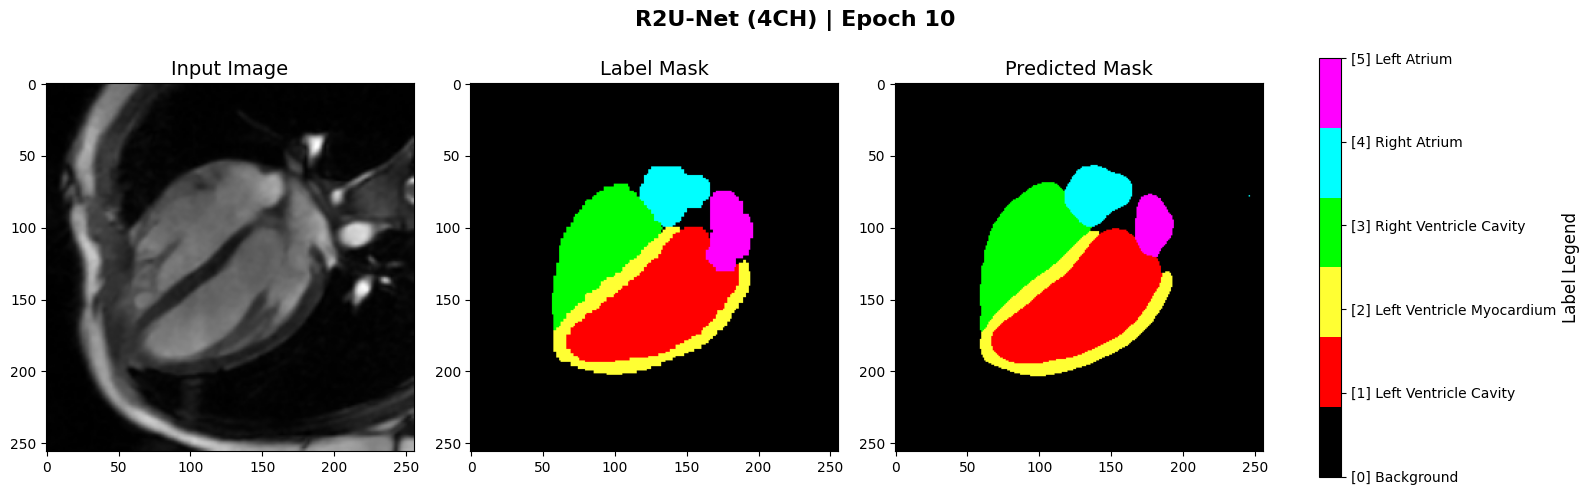

In [21]:
# ============================================
# 🎨 Professional Medical Visualization
# 4CH / 6 Classes
# ============================================

import random
import torch
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.colors import ListedColormap

# ============================================
# 📌 Model Name
# ============================================

MODEL_NAME  = "R2U-Net (4CH)"

# ============================================
# 📌 Load Checkpoint Info
# ============================================

checkpoint = torch.load(

    checkpoint_path,

    map_location=device,

    weights_only=False

)

epoch_num = checkpoint["epoch"] + 1

# ============================================
# 📌 Class Labels
# ============================================

CLASS_NAMES = [

    "[0] Background",

    "[1] Left Ventricle Cavity",

    "[2] Left Ventricle Myocardium",

    "[3] Right Ventricle Cavity",

    "[4] Right Atrium",

    "[5] Left Atrium"

]

# ============================================
# 🎨 Colors
# ============================================

COLORS = [

    (0, 0, 0),        # Background → Black

    (1, 0, 0),        # LV Cavity → Red

    (1, 1, 0.2),      # LV Myocardium → Yellow

    (0, 1, 0),        # RV Cavity → Green

    (0, 1, 1),        # Right Atrium → Cyan

    (1, 0, 1)         # Left Atrium → Magenta

]

CMAP = ListedColormap(COLORS)

# ============================================
# 🧠 Prediction
# ============================================

model.eval()

images, masks = next(iter(test_loader))

images = images.to(device)

with torch.no_grad():

    outputs = model(images)

    preds = torch.argmax(outputs, dim=1)

images = images.cpu()

masks = masks.cpu()

preds = preds.cpu()

# ============================================
# 🎲 Random Sample
# ============================================

idx = random.randint(
    0,
    images.shape[0] - 1
)

img = images[idx].squeeze().numpy()

gt = masks[idx].numpy()

pr = preds[idx].numpy()

# ============================================
# 📊 Plot Figure
# ============================================

fig, axes = plt.subplots(

    1,
    4,

    figsize=(16,5),

    gridspec_kw={
        'width_ratios': [1,1,1,0.06]
    }

)

# ============================================
# 🖼️ Input Image
# ============================================

axes[0].imshow(
    img,
    cmap='gray'
)

axes[0].set_title(
    "Input Image",
    fontsize=14
)

axes[0].axis('on')

# ============================================
# 🎯 Ground Truth
# ============================================

axes[1].imshow(

    gt,

    cmap=CMAP,

    vmin=0,

    vmax=5

)

axes[1].set_title(

    "Label Mask",

    fontsize=14

)

axes[1].axis('on')

# ============================================
# 🤖 Prediction
# ============================================

axes[2].imshow(

    pr,

    cmap=CMAP,

    vmin=0,

    vmax=5

)

axes[2].set_title(

    "Predicted Mask",

    fontsize=14

)

axes[2].axis('on')

# ============================================
# 🎨 Colorbar
# ============================================

norm = plt.Normalize(
    vmin=0,
    vmax=5
)

cbar = plt.colorbar(

    plt.cm.ScalarMappable(

        norm=norm,

        cmap=CMAP

    ),

    cax=axes[3]

)

cbar.set_ticks(
    np.arange(len(CLASS_NAMES))
)

cbar.set_ticklabels(CLASS_NAMES)

cbar.ax.set_ylabel(

    "Label Legend",

    rotation=90,

    fontsize=12

)

# ============================================
# 🏷️ Main Title
# ============================================

plt.suptitle(

    f"{MODEL_NAME} | Epoch {epoch_num}",

    fontsize=16,

    fontweight='bold'

)

plt.tight_layout()

plt.show()